#DATA PROCESSING CELL

In [38]:
import numpy as np
import math
from uncertainties import unumpy as unp
from uncertainties import ufloat as uf
import numpy as np
import uncertainties.umath as umath

def print_uarrays(*arrays, names=None):
    """
    Print uncertainty arrays side-by-side, rounding to the first
    significant digit of the uncertainty.

    Parameters
    ----------
    *arrays : uarray-like
        Arrays of uncertainty-aware numbers.
    names : list[str], optional
        Column names printed above the data.
    """
    arrays = [np.asarray(a) for a in arrays]

    if names is not None and len(names) != len(arrays):
        raise ValueError("Number of names must match number of arrays.")

    if not arrays:
        return

    columns = []

    for arr in arrays:
        values = unp.nominal_values(arr)
        errors = unp.std_devs(arr)

        formatted = []

        for value, error in zip(values, errors):
            if error == 0:
                formatted.append(str(value))
                continue

            # First significant digit of uncertainty
            exponent = int(np.floor(np.log10(abs(error))))
            decimals = -exponent

            # Round both value and uncertainty to that decimal place
            value_r = round(value, decimals)
            error_r = round(error, decimals)

            formatted.append(f"{value_r:.{max(0, decimals)}f} ± "
                             f"{error_r:.{max(0, decimals)}f}")

        columns.append(formatted)

    # Column widths
    widths = [
        max(len(header), *(len(x) for x in column))
        for header, column in zip(
            names if names else [""] * len(columns), columns
        )
    ]

    # Header
    if names:
        print("  ".join(f"{name:>{width}}" for name, width in zip(names, widths)))
        print("  ".join("-" * width for width in widths))

    # Rows
    for row in zip(*columns):
        print("  ".join(f"{value:>{width}}" for value, width in zip(row, widths)))

In [45]:
import pandas as pd

#Relevant Constants
beaker_weight = 282/1000 # kg
water_density = 1000 #kg/m3
g_acc = 9.81 #m/s2


#Loading Raw Data
raw_data = pd.read_csv('data.dat', sep=',', skiprows=1)
raw_data["weight_kg"] = raw_data["weight_g"]/1000
raw_data["weight_kg"] = (raw_data["weight_kg"] - beaker_weight)
print(raw_data)

    P1_cm  P2_cm  weight_g   time  weight_kg
0    77.0   63.0       644  34.39      0.362
1    67.0   55.0       491  19.16      0.209
2    57.0   47.0       476  19.85      0.194
3    49.0   41.0       427  15.70      0.145
4    47.0   39.0       434  17.63      0.152
5    39.0   33.0       446  19.97      0.164
6    27.0   23.0       417  21.94      0.135
7    23.0   19.0       381  16.96      0.099
8    17.0   13.0       361  18.84      0.079
9    11.0    9.0       354  19.99      0.072
10    6.5    5.2       336  21.27      0.054


In [81]:
#Processing raw data into relevant quantities


#print(raw_data)

data = pd.DataFrame()
data["Qexp_m3/s"] = raw_data["weight_kg"]/(water_density*raw_data["time"])
data["pressure_diff_Pa"] = g_acc*water_density*(raw_data["P1_cm"] - raw_data["P2_cm"])/100

data["dP_unc"] = data["pressure_diff_Pa"]*0.1

Qexp_unc = []
Qexp_m3ps = data["Qexp_m3/s"].to_numpy()
times = raw_data["time"]
volumes = raw_data["weight_kg"].to_numpy()/water_density

dV=(1/100)/1000 #1g -> 0.0001kg
dt=0.001 #s

for idx in range(len(times)):
    t = times[idx]
    V = volumes[idx]
    dQ = abs(dV/t) + abs(dt*V/(t*t))
    dQ = Qexp_m3ps[idx]*dQ
    Qexp_unc.append(dQ)

#print(dQ)

data["Qexp_unc"] = Qexp_unc

print(data)

    Qexp_m3/s  pressure_diff_Pa   dP_unc      Qexp_unc
0    0.000011           1373.40  137.340  3.064087e-12
1    0.000011           1177.20  117.720  5.699395e-12
2    0.000010            981.00   98.100  4.928389e-12
3    0.000009            784.80   78.480  5.888025e-12
4    0.000009            784.80   78.480  4.894555e-12
5    0.000008            588.60   58.860  4.115705e-12
6    0.000006            392.40   39.240  2.806258e-12
7    0.000006            392.40   39.240  3.443792e-12
8    0.000004            392.40   39.240  2.226626e-12
9    0.000004            196.20   19.620  1.802450e-12
10   0.000003            127.53   12.753  1.193903e-12


In [82]:

#Diameters and Areas
class tube_info:
    D1 = uf(7.75,0.05)/1000 #m
    D2 = uf(3.10, 0.05)/1000 #m

    A1 = np.pi * D1*D1/4 #m2
    A2 = np.pi * D2*D2/4 #m2


def ideal_flux(pressure_diff, A1=tube_info.A1, A2=tube_info.A2):
    Qcalc = umath.sqrt(2*pressure_diff/water_density)
    Qcalc*=A1
    Qcalc/=umath.sqrt((A1*A1)/(A2*A2) - 1)
    return Qcalc

def Re_calc(Qexp, diam=tube_info.D2):
    viscosity_of_water = 1.002/1000 #Pa*s
    A = np.pi*D1*D1/4
    v = Qexp/A
    Re = diam*water_density*v/viscosity_of_water
    return Re

press_diff = unp.uarray(data["pressure_diff_Pa"], data["dP_unc"])
Qexp_arr = unp.uarray(data["Qexp_m3/s"], data["Qexp_unc"])



#print(Qexp)

Qcalc_example = ideal_flux(press_diff[0])
print("Uncertainty propagation example:")
print(Qcalc_example)



Qcalc_arr = []
Cd_arr = []
Re_arr = []

print("Do I have the correct lenghts?", len(press_diff)==len(Qexp_arr))

for idx in range(len(press_diff)):
    Qcalc = ideal_flux(press_diff[idx])
    Qcalc_arr.append(Qcalc)
    
    Cd = Qexp_arr[idx]/Qcalc_arr[idx]
    Cd_arr.append(Cd)

    Re = Re_calc(Qexp_arr[idx])
    Re_arr.append(Re)


#print(Cd_arr)
print_uarrays(Qexp_arr, Qcalc_arr, Cd_arr, Re_arr, names=["Qexp m3/s","QCalc m3/s", "Cd", "Re"])

Uncertainty propagation example:
(1.27+/-0.08)e-05
Do I have the correct lenghts? True
                      Qexp m3/s             QCalc m3/s           Cd        Re
-------------------------------  ---------------------  -----------  --------
0.000010526316 ± 0.000000000003  0.0000127 ± 0.0000008  0.83 ± 0.05  690 ± 10
0.000010908142 ± 0.000000000006  0.0000117 ± 0.0000007  0.93 ± 0.06  720 ± 10
0.000009773300 ± 0.000000000005  0.0000107 ± 0.0000006  0.91 ± 0.05  640 ± 10
0.000009235669 ± 0.000000000006  0.0000096 ± 0.0000006  0.96 ± 0.06  610 ± 10
0.000008621668 ± 0.000000000005  0.0000096 ± 0.0000006  0.90 ± 0.05  570 ± 10
0.000008212318 ± 0.000000000004  0.0000083 ± 0.0000005  0.99 ± 0.06  540 ± 10
0.000006153145 ± 0.000000000003  0.0000068 ± 0.0000004  0.91 ± 0.05   404 ± 8
0.000005837264 ± 0.000000000003  0.0000068 ± 0.0000004  0.86 ± 0.05   383 ± 8
0.000004193206 ± 0.000000000002  0.0000068 ± 0.0000004  0.62 ± 0.04   275 ± 6
0.000003601801 ± 0.000000000002  0.0000048 ± 0.0000003 

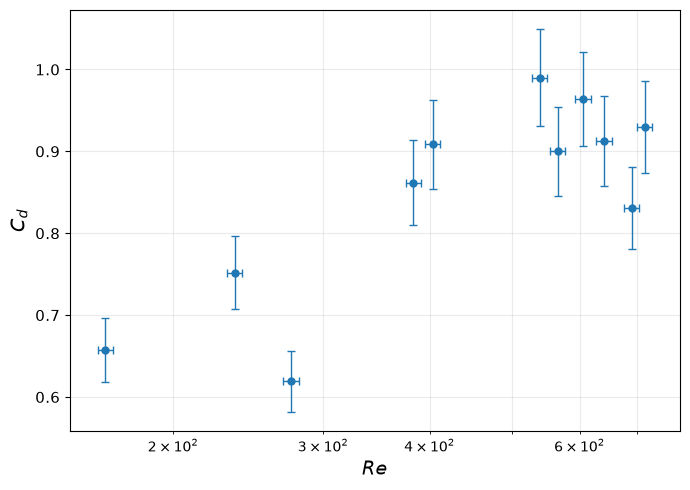

In [83]:
import matplotlib.pyplot as plt

Re_values = unp.nominal_values(Re_arr)
dRe = unp.std_devs(Re_arr)

Cd_values = unp.nominal_values(Cd_arr)
dCd = unp.std_devs(Cd_arr)

plt.figure(figsize=(7, 5))

plt.errorbar(
    Re_values, Cd_values,
    xerr=dRe,
    yerr=dCd,
    fmt="o",
    capsize=3,
    markersize=5,
    linewidth=1
)

plt.xscale("log")

plt.xlabel(r"$Re$", fontsize=14)
plt.ylabel(r"$C_d$", fontsize=14)

plt.grid(True, which="both", alpha=0.25)
plt.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()